In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import r2_score
import xarray as xr
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import ensemble

In [3]:
scores = xr.open_dataset("../scoring/scores/scores2.nc")

param0 = pd.read_csv('../proccessing_ensemble/lhs_np15_ns3000_values.txt', sep='\s+')
ds = param0.to_xarray()
param0 = ds.rename({'index': 'sim'})

param=param0.drop_vars(['ytill.cf_negis_centre', 'ytill.cf_negis_south'])
new_order = ['itm.itm_b', 'itm.itm_c', 'marine_shelf.kappa_grz','snap.f_p_ne','ymat.enh_shear','ydyn.beta_q', 'ytill.z0','yneff.delta','ytopo.kt','isostasy.tau','isostasy.He_lith','ytill.cf_negis_north','ctrl.cf_negis_1']
param = param[new_order]

y = scores["S"].to_dataframe()
X = param.to_dataframe()

train_ds, val_ds = train_test_split(scores.sim.values, train_size=0.9, test_size=0.1)
y = scores["S"].to_dataframe()
X = param.to_dataframe()

df_X_train = X.loc[train_ds]
df_X_val = X.loc[val_ds]
df_y_train = y.loc[train_ds]
df_y_val = y.loc[val_ds]

X_train = df_X_train.values
X_val = df_X_val.values
y_train = df_y_train.values
y_val = df_y_val.values




<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_475243/453670702.py:3: SyntaxWarning: invalid escape sequence '\s'
  param0 = pd.read_csv('../proccessing_ensemble/lhs_np15_ns3000_values.txt', sep='\s+')


In [4]:
param_names = {
    'itm.itm_b': 'b',
    'itm.itm_c': 'c$_{\mathrm{1}}$',
    'ydyn.beta_q': 'q',
    'ytill.z0': 'z$_{\mathrm{0}}$',
    'yneff.delta': '$\delta$',
    'ymat.enh_shear': 'E$_{\mathrm{shear}}$',
    'marine_shelf.kappa_grz': '$\kappa$',
    'isostasy.tau': '$\\tau$',
    'isostasy.He_lith': 'H$_{\mathrm{e}}$',
    'ytopo.kt': 'K$_{\mathrm{t}}$',
    'ytill.cf_negis_north': 'f$_{\mathrm{mid}}$',
    'snap.f_p_ne': 'f$_{\mathrm{p}}$',
    'ctrl.cf_negis_1': 'f$_{\mathrm{low}}$'
}

param_units = {
    'itm.itm_b': 'W m$^{-2}$',
    'itm.itm_c': 'W m$^{-2}$',
    'ydyn.beta_q': '-',
    'ytill.z0': 'm',
    'yneff.delta': '-',
    'ymat.enh_shear': '-',
    'marine_shelf.kappa_grz': 'm yr$^{-1}$ K$^{-1}$',
    'isostasy.tau': 'yr',
    'isostasy.He_lith': 'km',
    'ytopo.kt': 'm yr$^{-1}$ Pa$^{-1}$',
    'ytill.cf_negis_north': '-',
    'snap.f_p_ne': '-',
    'ctrl.cf_negis_1': '-'
}
scores_names={"S": "S",
    "S_H_ice": "S$_{\mathrm{Hice}}$",
    "S_ice_cover": "S$_{{\mathrm{ice \, cover}}}$",
    "S_z_bed": "S$_{\mathrm{z \, bed}}$",
    "S_uxy": "S$_{\mathrm{uxy}}$",
    "S_grip": "S$_{\mathrm{GRIP}}$",
    "S_ngrip": "S$_{\mathrm{NGRIP}}$",
    "S_dye3": "S$_{\mathrm{DYE3}}$",
    "S_isocr": "S$_{\mathrm{iso}}$",
    "S_lgm": "S$_{\mathrm{LGM}}$"
}

feature_names = [param_names.get(col, col) for col in X.columns]
feature_unit = [param_units.get(col, col) for col in X.columns]

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\k'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape 

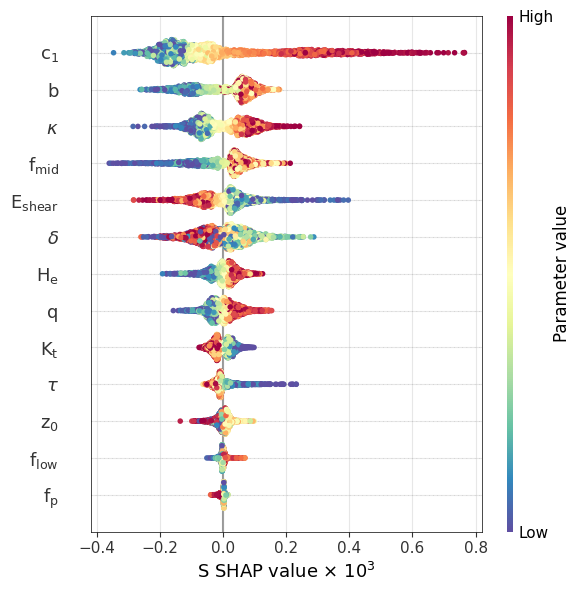

In [7]:
best = xgb.XGBRegressor()
best.load_model("../scoring/output/xgboost_for_scores2.json")

explainer = shap.TreeExplainer(best)
shap_values = explainer.shap_values(X)

fig, ax = plt.subplots()
plt.sca(ax)
shap.summary_plot(
    shap_values * 1000, 
    X, 
    feature_names=feature_names,
    show=False, 
    cmap="Spectral_r",
    plot_size=(6, 6)
)

ax.set_xlabel("S SHAP value × $10^{3}$")
all_axes = fig.get_axes()
if len(all_axes) > 1:
    cax = all_axes[-1] 
    cax.set_ylabel('Parameter value')
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5) 
ax.grid(True, alpha=0.3)

plt.savefig("../figs_final/fig13_shap_summary_plot.png", dpi=300, bbox_inches='tight')

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_475243/1278426856.py:20: SyntaxWarning: invalid escape sequence '\m'
  if col == 'K$_{\mathrm{t}}$':


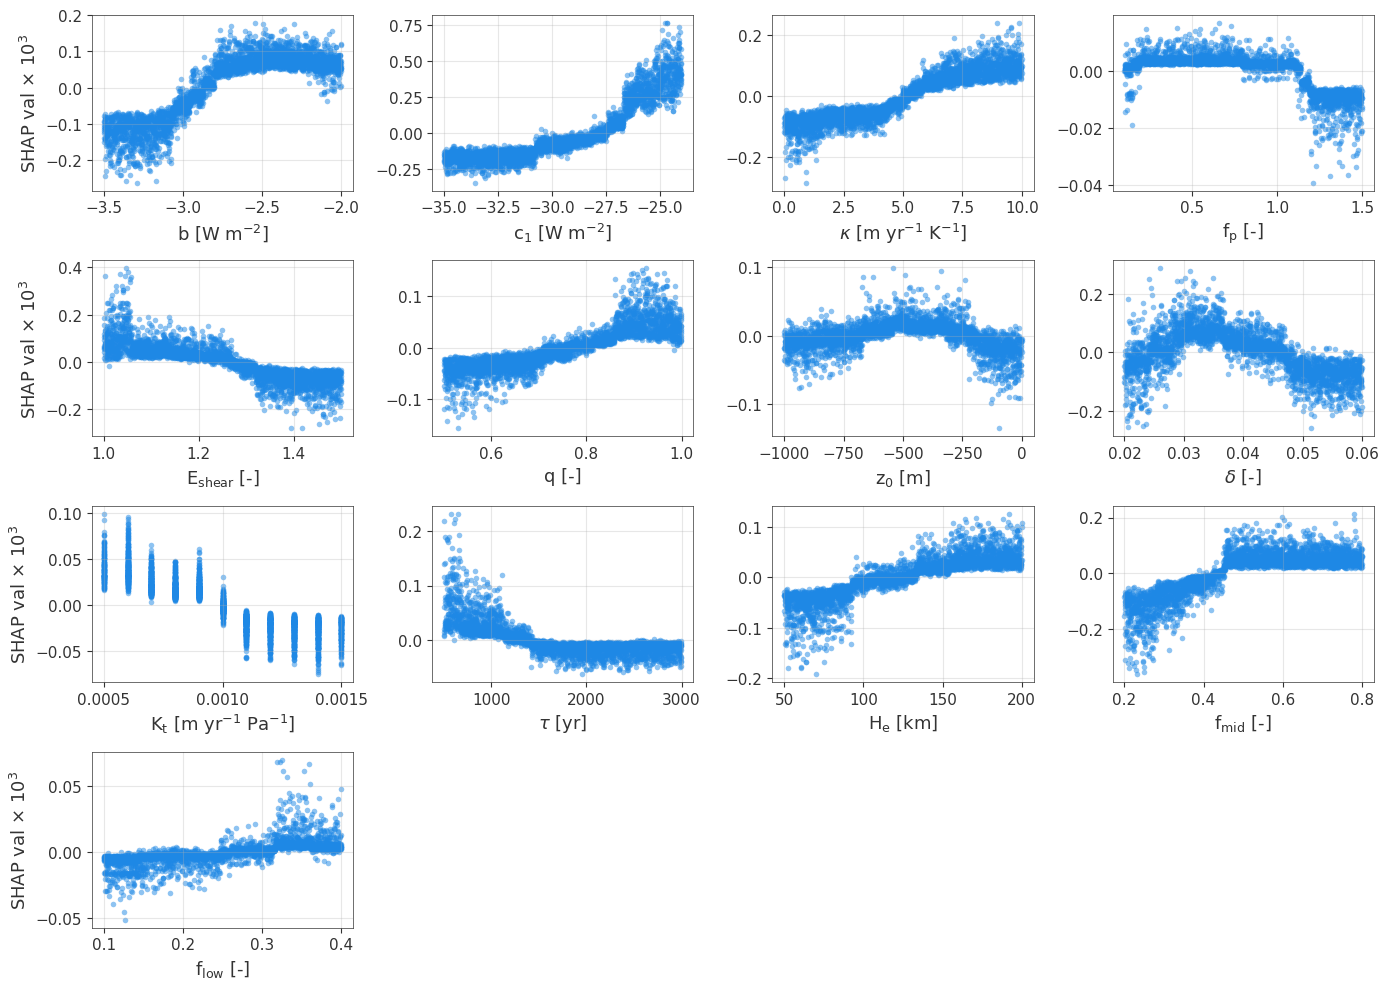

In [16]:
n_features = len(feature_names)
cols = 4 
rows = 4

fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(feature_names):
    ax = axes[i]
    
    idx = feature_names.index(col)
    unit = feature_unit[idx]
    shap.dependence_plot(idx,shap_values*1e3,X,ax=ax,show=False,interaction_index=None,alpha=0.5)
    
    if i in [0, 4, 8, 12]:
        ax.set_ylabel("SHAP val × $10^{3}$")
    else: 
        ax.set_ylabel("")

    if col == 'K$_{\mathrm{t}}$':
        ax.set_xticks([0.0005,0.001,0.00150])

    ax.set_xlabel(f"{col} [{unit}]")
    ax.grid(alpha=0.3,zorder=1)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5) 


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("../figs_final/figS1_shap_scatter_plot.png", dpi=300)